SmartCart Clustering System
Problem Statement
SmartCart is a growing e-commerce platform serving customers across multiple
countries. The company collected extensive customer data consisting Of 2240
customer records and 22 attributes including demographics, purchase behaviour,
website activity, and response.
Currently, SmartCart uses generic marketing and engagement strategies for all
customers, without clearly understanding different customer behaviour patterns.
This results in inefficient marketing, missed opportunities to retain high-value
customers, and delayed identification of churn-prone users.
To solve this, SmartCart aims to build an intelligent customer segmentation
system using unsupervised machine learning. The system will analyse historical
customer transaction data and group customers into meaningful clusters based
on purchasing behaviour, engagement levels, and loyalty indicators.
You are hired as an AIIML Engineer to develop this system using clustering
algorithms to discover hidden patterns in customer behaviour and support data-
driven decision-making for personalised marketing and customer retention.

In [58]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("smartcart_customers.csv")

In [59]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [60]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [61]:
# Data Preprocessing

## handle all the missing values

df["Income"] = df["Income"].fillna(df["Income"].median())

In [62]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [63]:
# ex - Age will be better than the date of birth 

df["Age"] = 2026 - df["Year_Birth"]


In [64]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [65]:
# Customer Tenure Days - joining date as date is not well validated by clustering algo

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_data = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_data - df["Dt_Customer"]).dt.days

In [66]:
df.head()

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [67]:
## spending as can convert this into total spending

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [68]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

In [69]:
df["Education"].value_counts()




Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [70]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [71]:
## we will make it in 3 categories

# undegrad, grad, postgrad

df["Education"]=df["Education"].replace({
    "Basic" : "Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD" : "Postgraduate"
})



In [72]:
#marital status

df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [73]:
#marital status


df["Living_With"]=df["Marital_Status"].replace({
    "Married" : "Partner","Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow" : "Alone","Alone":"Alone",
        "Absurd" : "Alone",
        "YOLO" : "Alone"
})


## DROP COLUMNS


In [74]:
df.head()

df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_spending',
       'Total_children', 'Living_With'],
      dtype='object')

In [75]:
cols = ["ID", "Year_Birth", "Marital_Status","Teenhome","Kidhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [76]:
df_cleaned.shape

(2240, 15)

In [77]:
df_cleaned

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner
2236,Postgraduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone
2238,Postgraduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner


### Outliers


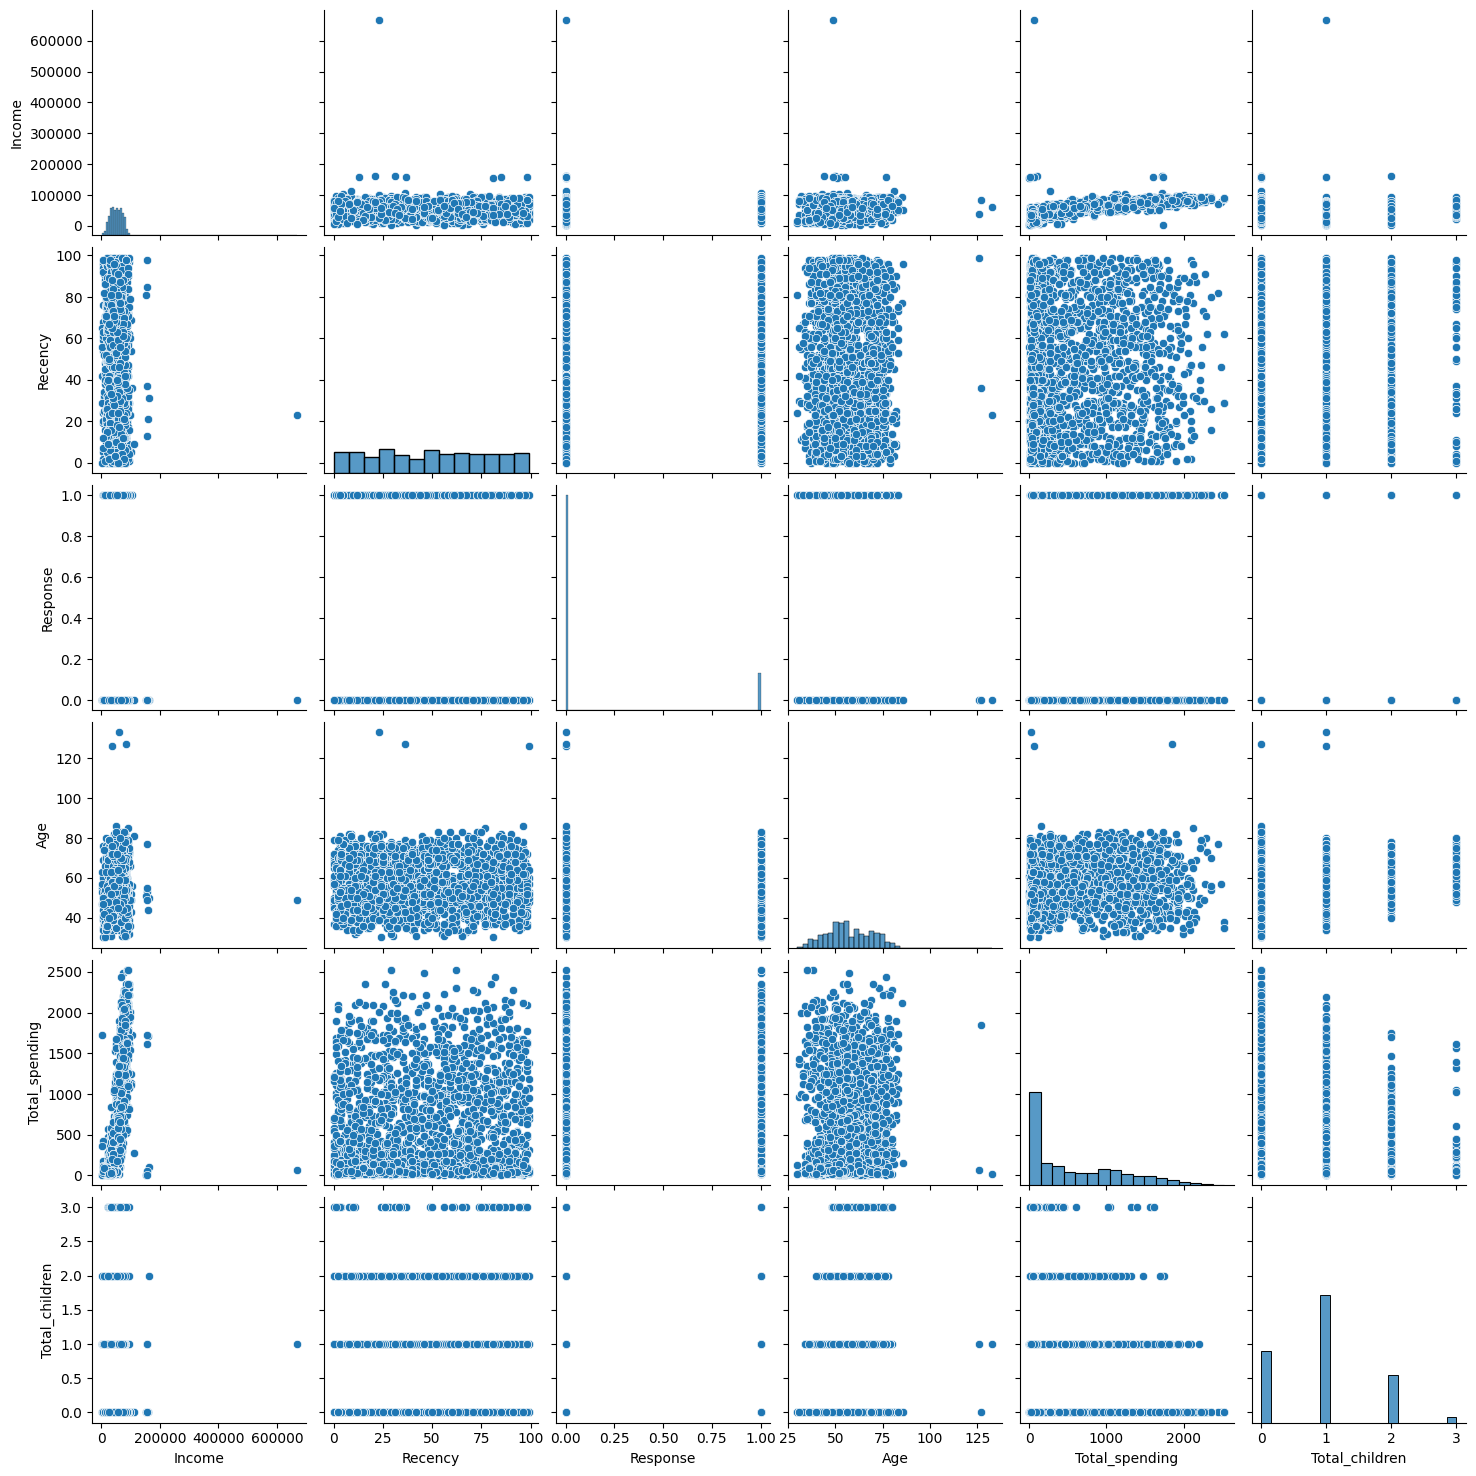

In [78]:
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_children"]

# Relative plots of some features - pair plot 

sns.pairplot(df_cleaned[cols])

In [79]:
# remove the outliers 

print("data size with outliers : ", len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"] < 90 ]
df_cleaned = df_cleaned[df_cleaned["Income"] < 60_0000]

print(f"without outliers {len(df_cleaned)}")

data size with outliers :  2240
without outliers 2236


### HeatMaps

<Axes: >

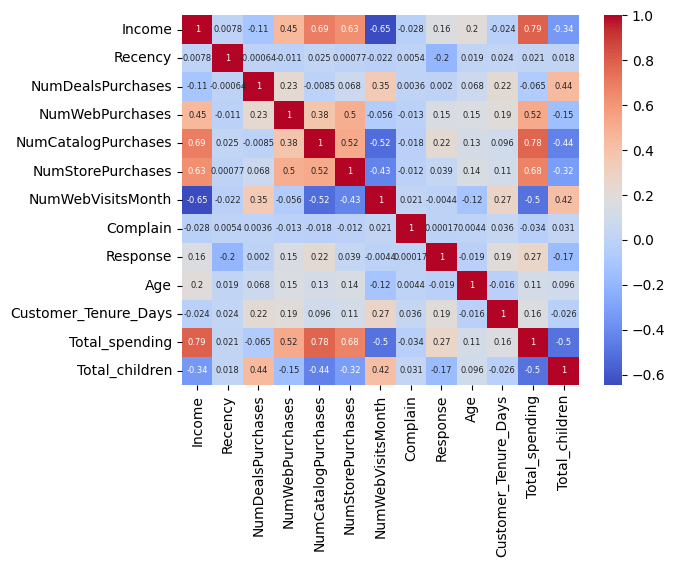

In [80]:
corr = df_cleaned.corr(numeric_only=True)

plt.Figure(figsize=(8,6))

sns.heatmap(
      corr,
      annot=True,
      annot_kws={"size":6},
      cmap="coolwarm"
)

In [81]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_spending', 'Total_children',
       'Living_With'],
      dtype='object')

### Encoding

In [82]:
from sklearn.preprocessing import OneHotEncoder

In [83]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols =  ohe.fit_transform(df_cleaned[cat_cols])

In [84]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [85]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [86]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [87]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [88]:
# Scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_encoded

X_scaled = scaler.fit_transform(X)

## Visualise


In [89]:
X_scaled.shape

# this can't be visualised, with that many features hence we would be requiring PCA for this 
# 2D

from sklearn.decomposition import PCA


In [90]:
pca = PCA(n_components=3)

In [91]:
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D projection ')

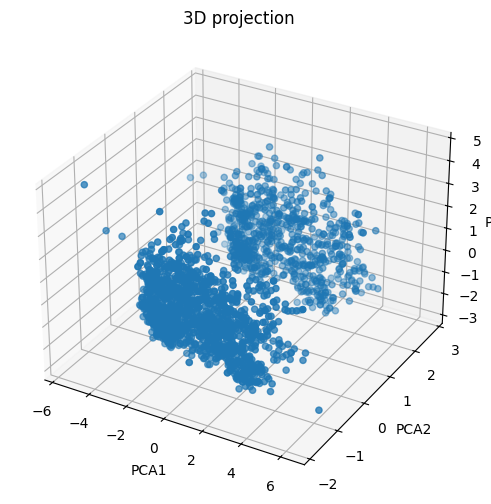

In [92]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

ax.set_title("3D projection ")

In [93]:
pca.explained_variance_ratio_

# this ratio is 23+11 = 34 % variance is captured but majority info is lost 

array([0.23163158, 0.11385454, 0.10405815])

// comparing the k means and agglomerative Hierarchial clustering 

### Analyse K values

#### Elbow method

In [94]:
# for this clustering, we need 5-6 clusters to form in order to divide customers not more than that

# so k varies from 1 to 10

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [95]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [96]:
int(optimal_k)

4

Text(0, 0.5, 'WCSS')

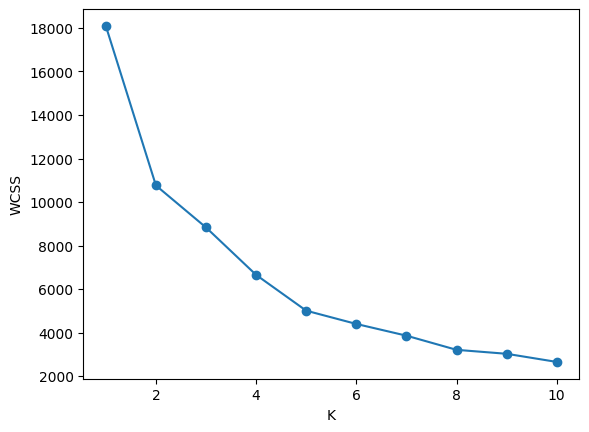

In [97]:
# plot 

plt.plot(range(1,11), wcss , marker='o')

plt.xlabel("K")
plt.ylabel("WCSS")


#### 2. Silhouette Score

Text(0, 0.5, 'Silhouette Score')

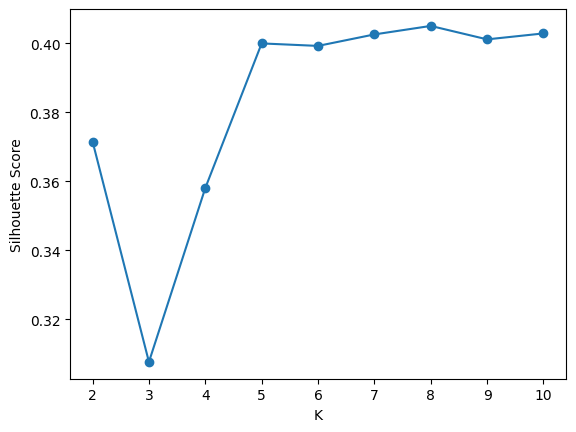

In [98]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot 

plt.plot(range(2,11), scores , marker='o')

plt.xlabel("K")
plt.ylabel("Silhouette Score")



Text(0, 0.5, 'SS')

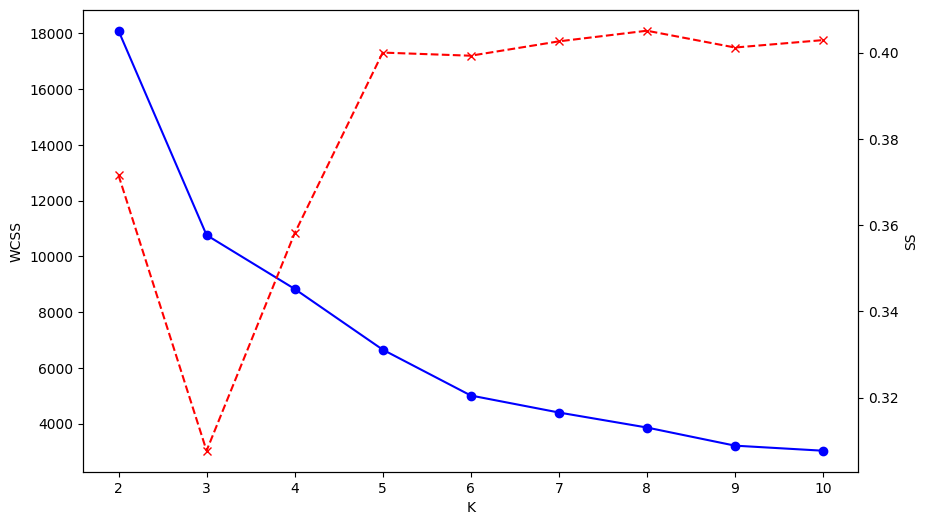

In [99]:
## combined plot, the intersection of both plot gives the best k value

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(k_range,wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

### Clustering

In [100]:
# K means 

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

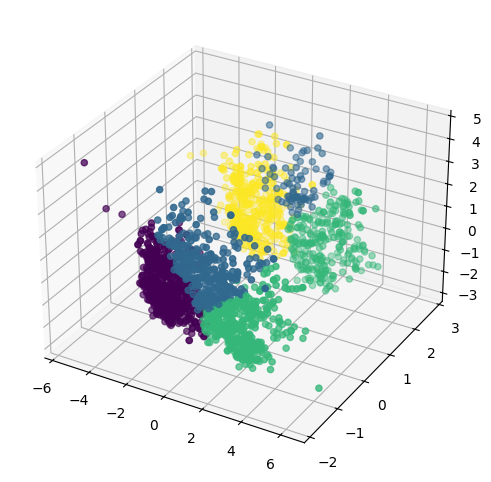

In [101]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)


#### Agglomerative Clustering

In [102]:
from sklearn.cluster import AgglomerativeClustering

In [103]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
lables_agg = agg_clf.fit_predict(X_pca)

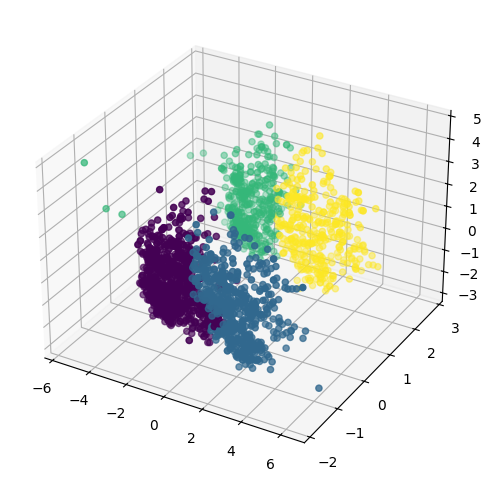

In [104]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=lables_agg)


## Characterization of Clusters

In [105]:
X["cluster"] = lables_agg

X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


C:\Users\devan\AppData\Local\Temp\ipykernel_5168\2674553874.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X, x="cluster", palette=pal)


Text(0.5, 1.0, 'Cluster Distribution')

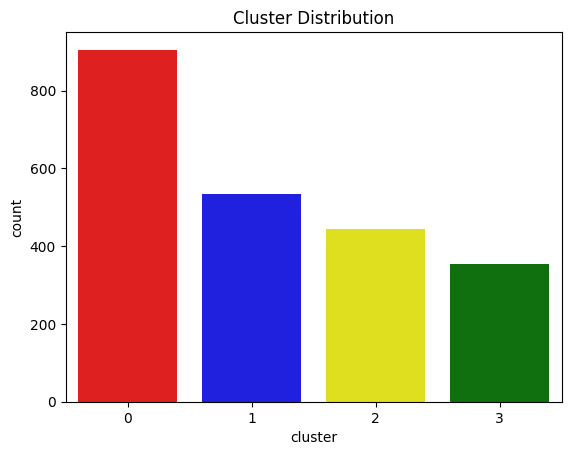

In [ ]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(data=X, x="cluster", palette=pal)
plt.title("Cluster Distribution")

<Axes: xlabel='Total_spending', ylabel='Income'>

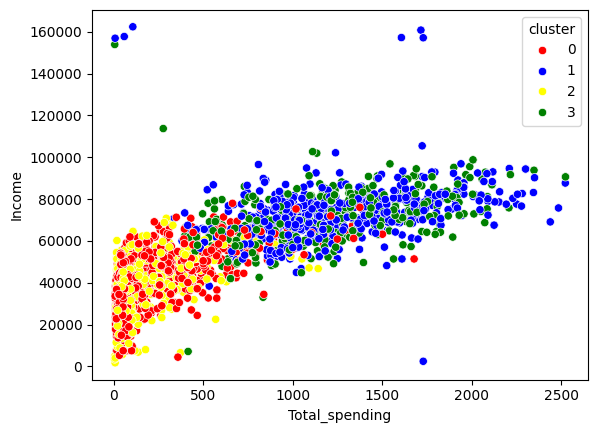

In [ ]:
#Income & spending patterns

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["cluster"],palette=pal )

In [ ]:
# CLuster Summary 

cluster_summary = X.groupby("cluster").mean()

print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         